# 1. Exploratory Data Analysis (EDA)
This notebook strictly follows the comprehensive EDA structure to ensure every insight is captured before moving to feature engineering.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')

# Load Data
df = pd.read_csv('synthetic_flood_data.csv')

## 1.1 Data Overview & Quality Check
Finding the shape, null/non-null values, missing values, duplicates, and zero values.

In [14]:
print('--- Data Shape ---')
print(df.shape)

print('\n--- Data Info (Non-Null Counts & Data Types) ---')
df.info()

print('\n--- Missing Values ---')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\n--- Duplicates ---')
print(df.duplicated().sum())

print('\n--- Zero Values Count ---')
print((df == 0).sum()[ (df == 0).sum() > 0 ])

--- Data Shape ---
(50000, 13)

--- Data Info (Non-Null Counts & Data Types) ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rain_1h_mm           50000 non-null  float64
 1   Rain_3h_mm           50000 non-null  float64
 2   Rain_24h_mm          50000 non-null  float64
 3   Forecast_Rain_3h_mm  49000 non-null  float64
 4   Soil_Moisture_Pct    50000 non-null  float64
 5   Slope_Deg            50000 non-null  float64
 6   Elevation_m          50000 non-null  float64
 7   Distance_to_River_m  50000 non-null  float64
 8   Land_Cover_Type      50000 non-null  int64  
 9   Flow_Accumulation    50000 non-null  float64
 10  River_Water_Level_m  49501 non-null  float64
 11  Risk_Score_Raw       50000 non-null  float64
 12  Flood_Risk_Label     50000 non-null  int64  
dtypes: float64(11), int64(2)
memory usage: 5.0 MB

--- Missing Values 

## 1.2 Structural Cleaning (Dropping Decoys & Noise)
Removing the data leakage column and handling the artificial sentinel values (broken IoT sensors) so they don't skew our histograms.

In [15]:
# Drop Decoy/Leakage Column
clean_df = df.drop(columns=['Risk_Score_Raw'])

# Handle sentinels (-999.0 and 9999.9)
clean_df.replace(-999.0, np.nan, inplace=True)
clean_df.replace(9999.9, np.nan, inplace=True)

print('Cleaning Complete. Decoy dropped and sentinels mapped to NaN.')

Cleaning Complete. Decoy dropped and sentinels mapped to NaN.


## 1.3 Mathematical Overview
Using `.describe()` to get statistical insights into the distributions.

In [16]:
display(clean_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Rain_1h_mm,49900.0,14.603101,30.419268,0.00,1.6500,4.090,9.0800,149.98
Rain_3h_mm,50000.0,24.595916,32.036496,0.09,7.4400,13.690,24.5000,211.21
Rain_24h_mm,50000.0,44.655517,37.689585,0.58,19.8700,32.820,54.7300,315.78
Forecast_Rain_3h_mm,49000.0,14.964913,14.967825,0.00,4.3300,10.340,20.6900,167.32
Soil_Moisture_Pct,50000.0,54.504969,26.363238,0.00,31.8700,54.565,77.2900,100.00
Slope_Deg,50000.0,31.041767,16.746092,2.00,16.4700,31.150,45.4900,60.00
Elevation_m,50000.0,1548.080310,835.721221,100.26,828.0475,1542.585,2268.1775,2999.89
Distance_to_River_m,50000.0,1008.100853,572.669326,10.06,514.1800,1004.570,1503.8950,1999.97
Land_Cover_Type,50000.0,2.005400,1.001934,1.00,1.0000,2.000,3.0000,4.00
Flow_Accumulation,50000.0,50.382117,28.559469,1.00,25.6800,50.430,74.9925,100.00


## 1.4 Univariate Analysis
Plotting histograms for EACH column to get an overview of individual distributions, alongside Box Plots and Count Plots.

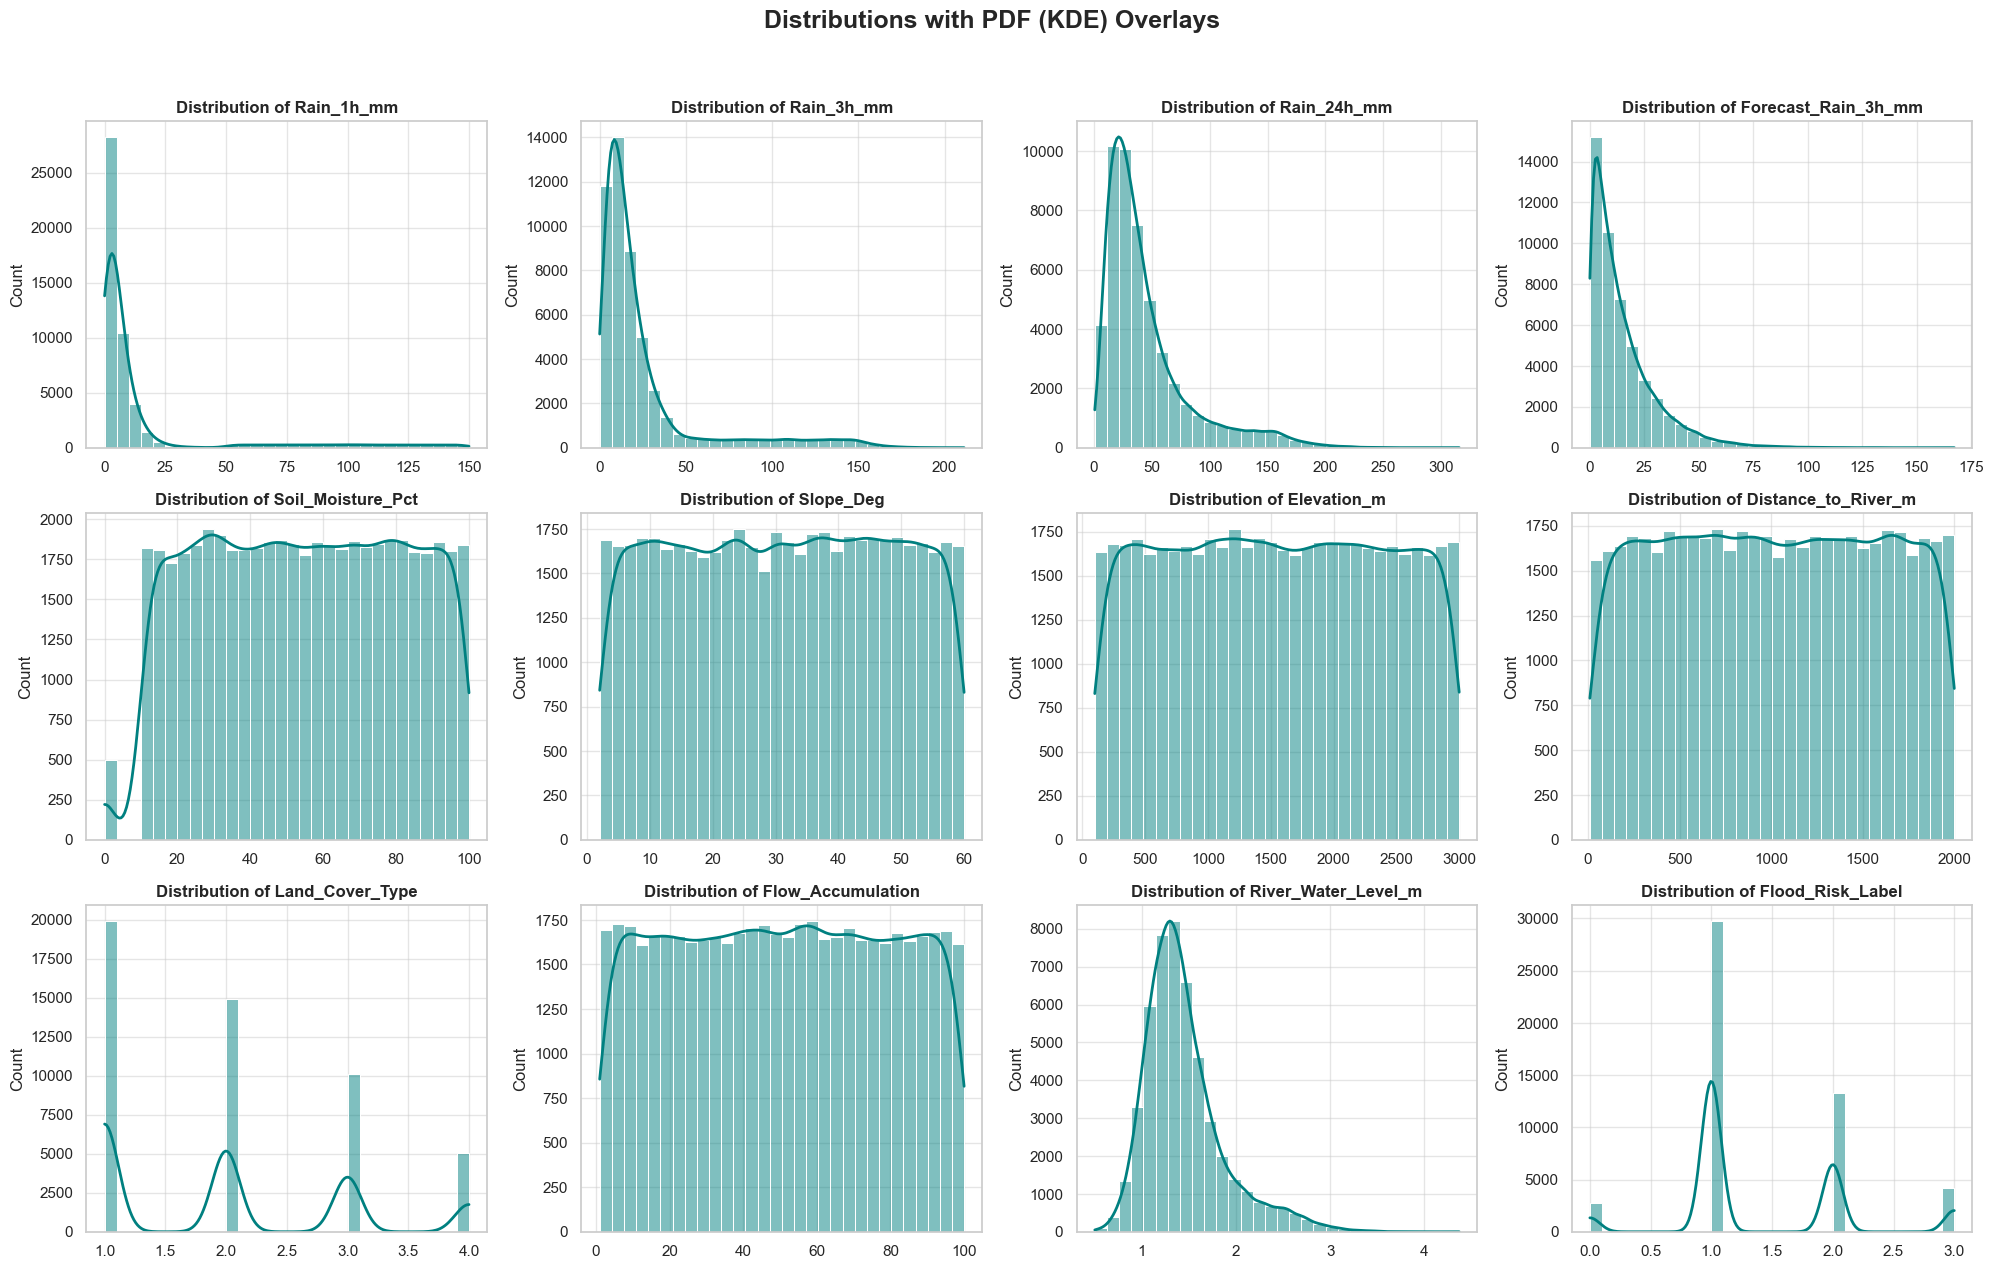

In [26]:
# 1. Histograms with PDF (KDE) for all numerical columns
num_cols = clean_df.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # sns.histplot is the modern standard for combining hist and kde
    sns.histplot(clean_df[col], kde=True, color='teal', bins=30, ax=axes[i], line_kws={'linewidth': 2})
    axes[i].set_title(f'Distribution of {col}', weight='bold')
    axes[i].set_xlabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions with PDF (KDE) Overlays', y=1.02, size=18, weight='bold')
plt.tight_layout()
plt.show()

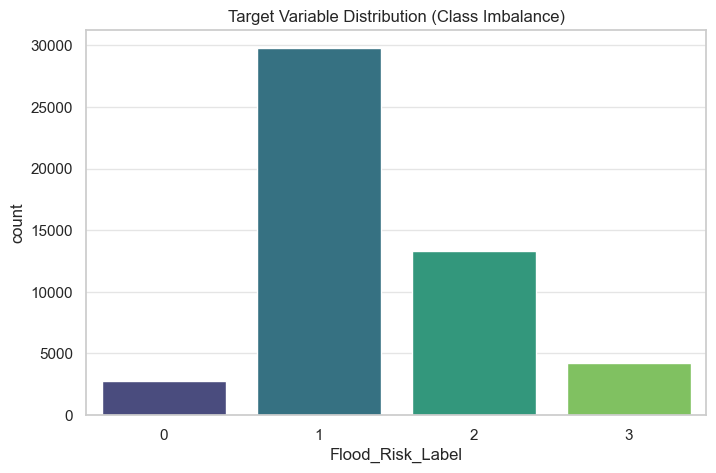

In [18]:
# 2. Count Plot for Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x='Flood_Risk_Label', palette='viridis')
plt.title('Target Variable Distribution (Class Imbalance)')
plt.show()

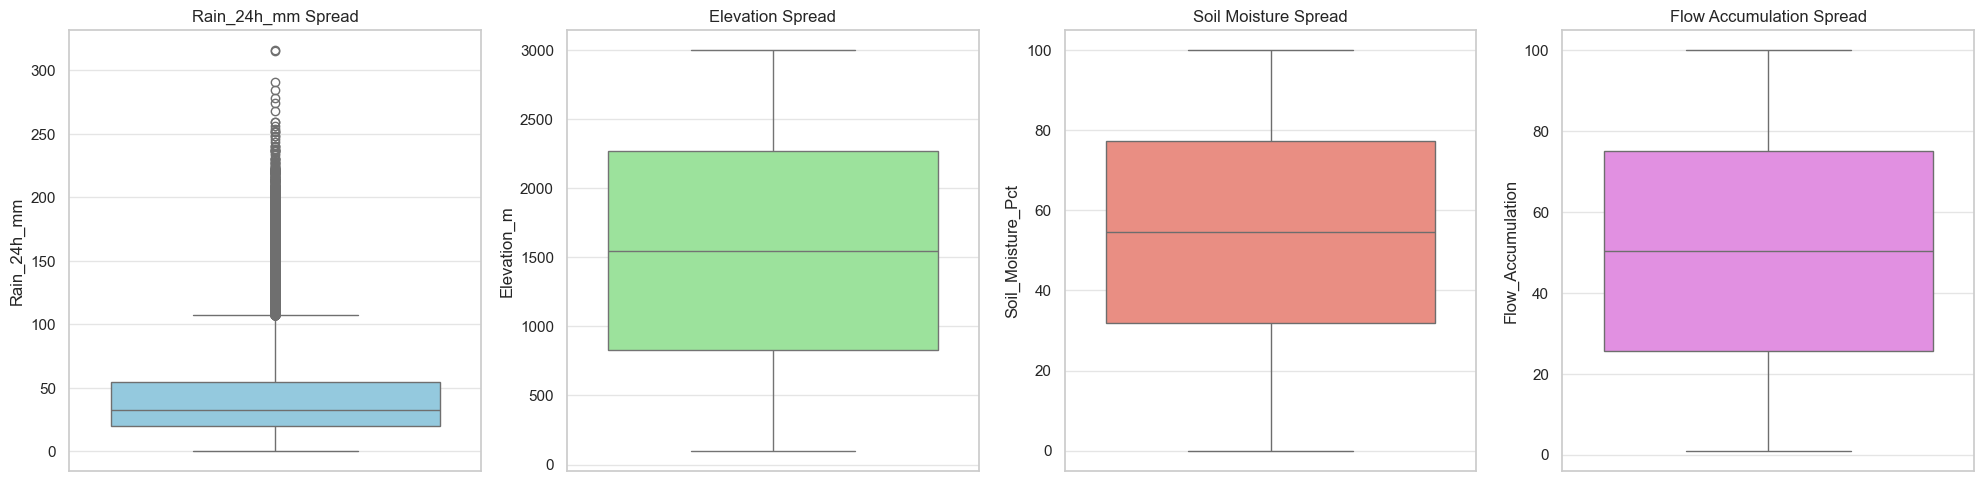

In [19]:
# 3. Box Plots for key physical drivers to spot outliers
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.boxplot(y=clean_df['Rain_24h_mm'], color='skyblue', ax=axes[0])
axes[0].set_title('Rain_24h_mm Spread')
sns.boxplot(y=clean_df['Elevation_m'], color='lightgreen', ax=axes[1])
axes[1].set_title('Elevation Spread')
sns.boxplot(y=clean_df['Soil_Moisture_Pct'], color='salmon', ax=axes[2])
axes[2].set_title('Soil Moisture Spread')
sns.boxplot(y=clean_df['Flow_Accumulation'], color='violet', ax=axes[3])
axes[3].set_title('Flow Accumulation Spread')
plt.tight_layout()
plt.show()

## 1.5 Bivariate Analysis
Using Scatter Plots and Regression Plots (`regplot`) to observe the direct relationship between continuous predictors and the target.

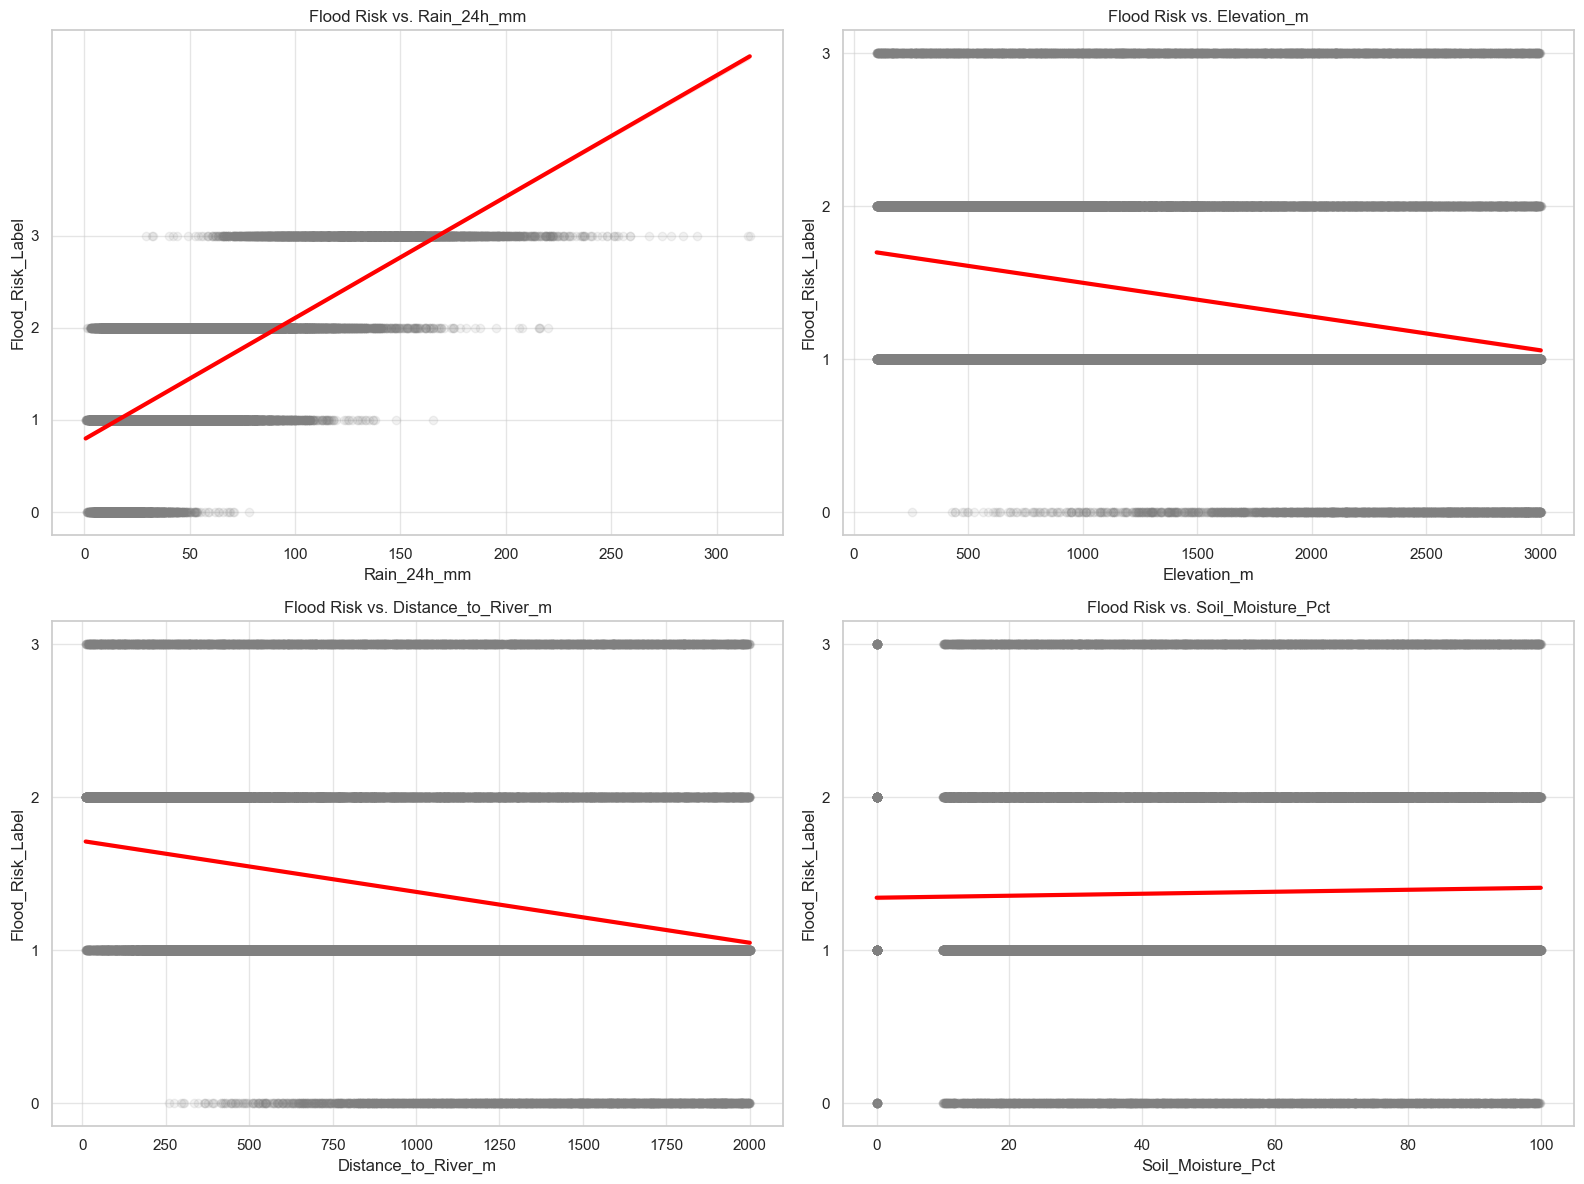

In [20]:
features_to_regress = ['Rain_24h_mm', 'Elevation_m', 'Distance_to_River_m', 'Soil_Moisture_Pct']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, feature in enumerate(features_to_regress):
    row = idx // 2
    col = idx % 2
    # Scatter + Regression Line
    sns.regplot(x=feature, y='Flood_Risk_Label', data=clean_df, ax=axes[row, col], 
                scatter_kws={'alpha':0.1, 'color': 'gray'}, 
                line_kws={'color':'red', 'linewidth': 3})
    axes[row, col].set_title(f'Flood Risk vs. {feature}')
    axes[row, col].set_yticks([0, 1, 2, 3])

plt.tight_layout()
plt.show()

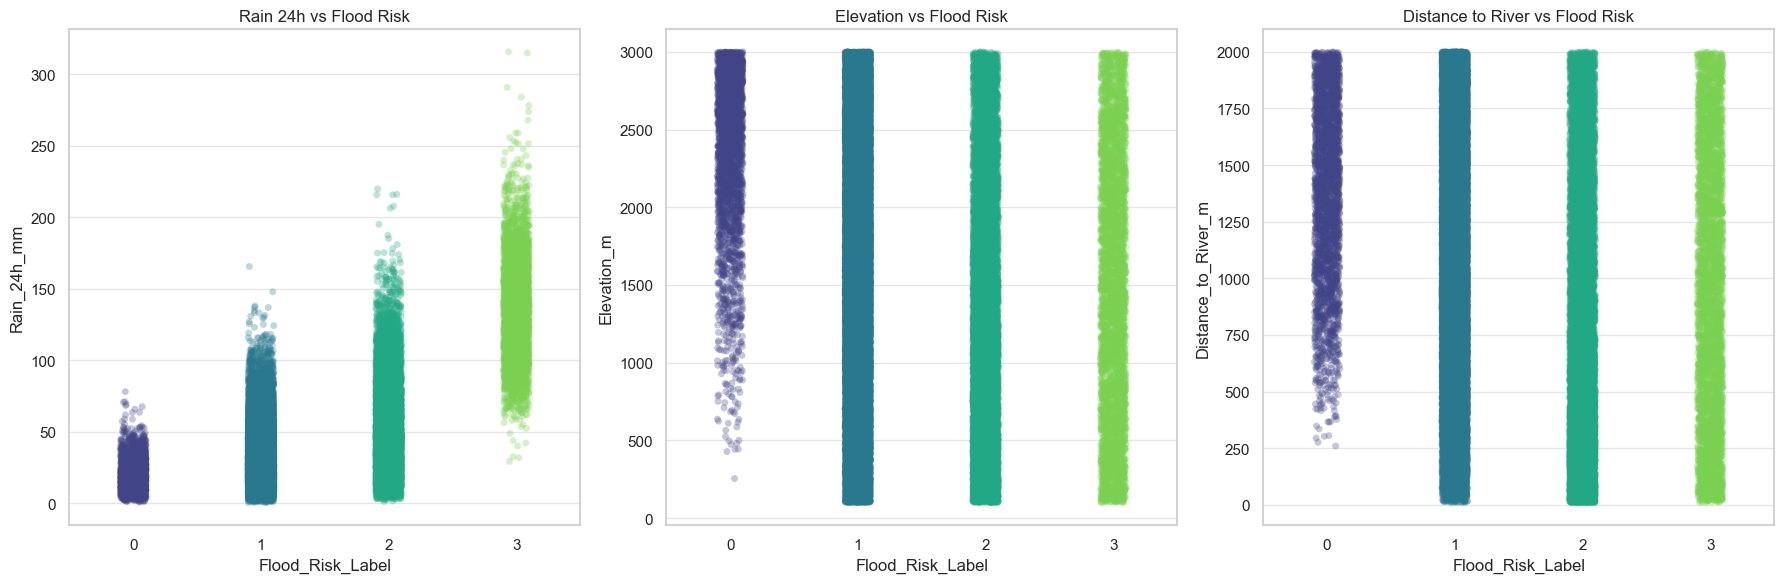

INSIGHT: The strip plot reveals the extreme clustering of data points. Notice how heavily clustered Class 3 is at low elevations!


In [27]:
# 1.5b Bivariate Analysis: Strip Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.stripplot(x='Flood_Risk_Label', y='Rain_24h_mm', data=clean_df, palette='viridis', alpha=0.3, jitter=True, ax=axes[0])
axes[0].set_title('Rain 24h vs Flood Risk')

sns.stripplot(x='Flood_Risk_Label', y='Elevation_m', data=clean_df, palette='viridis', alpha=0.3, jitter=True, ax=axes[1])
axes[1].set_title('Elevation vs Flood Risk')

sns.stripplot(x='Flood_Risk_Label', y='Distance_to_River_m', data=clean_df, palette='viridis', alpha=0.3, jitter=True, ax=axes[2])
axes[2].set_title('Distance to River vs Flood Risk')

plt.tight_layout()
plt.show()

print("INSIGHT: The strip plot reveals the extreme clustering of data points. Notice how heavily clustered Class 3 is at low elevations!")

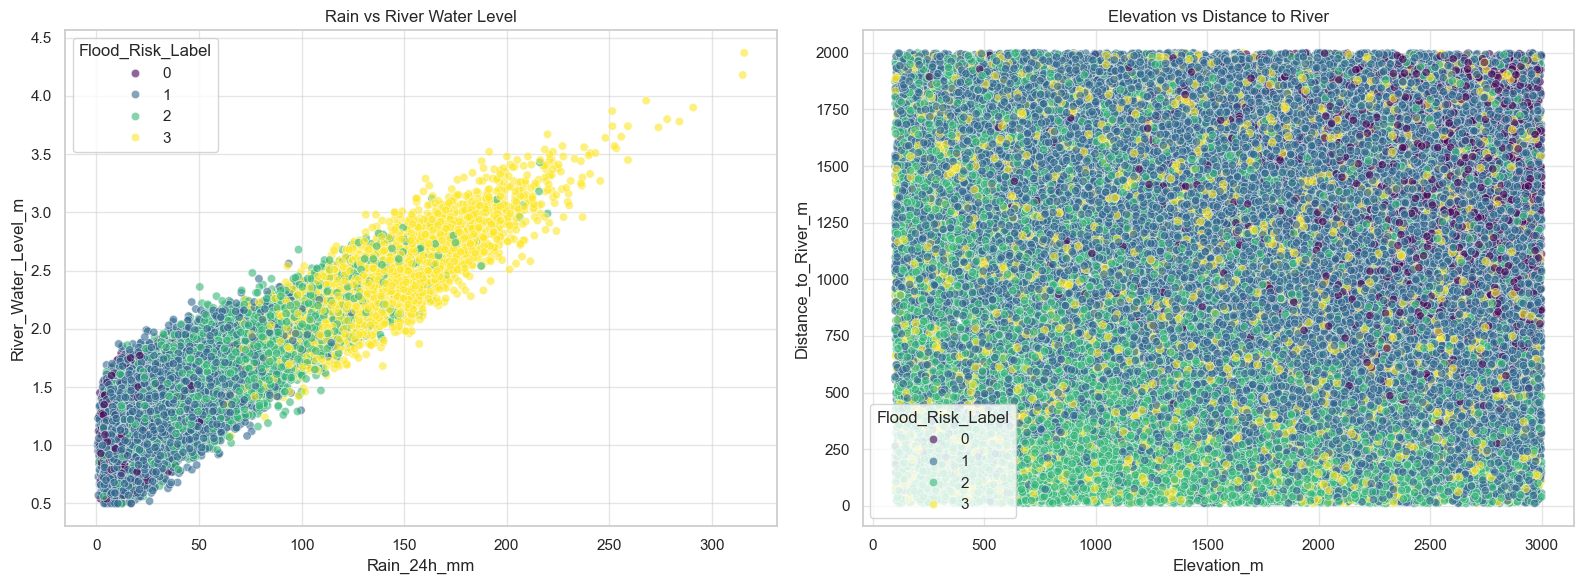

INSIGHT: Scatter Plot 1 shows massive 24h Rain directly correlates with dangerous River Levels.


In [28]:
# 1.5c Bivariate Analysis: Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter 1: Rain vs River Level
sns.scatterplot(x='Rain_24h_mm', y='River_Water_Level_m', hue='Flood_Risk_Label', data=clean_df, palette='viridis', alpha=0.6, ax=axes[0])
axes[0].set_title('Rain vs River Water Level')

# Scatter 2: Elevation vs Distance to River
sns.scatterplot(x='Elevation_m', y='Distance_to_River_m', hue='Flood_Risk_Label', data=clean_df, palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_title('Elevation vs Distance to River')

plt.tight_layout()
plt.show()

print("INSIGHT: Scatter Plot 1 shows massive 24h Rain directly correlates with dangerous River Levels.")

## 1.6 Multivariate Analysis
Using Heatmaps, Clustermaps, and Pairplots to find the most influential columns and observe complex feature interactions.

In [21]:
# 1. Covariance Matrix (Understanding the joint variability)
print('--- Covariance Matrix ---')
cov_matrix = clean_df.cov()
display(cov_matrix.style.background_gradient(cmap='coolwarm'))

# 2. Correlation Matrix (Understanding linear relationships)
print('\n--- Correlation Matrix ---')
corr = clean_df.corr()
display(corr.style.background_gradient(cmap='coolwarm'))

--- Covariance Matrix ---


,Rain_1h_mm,Rain_3h_mm,Rain_24h_mm,Forecast_Rain_3h_mm,Soil_Moisture_Pct,Slope_Deg,Elevation_m,Distance_to_River_m,Land_Cover_Type,Flow_Accumulation,River_Water_Level_m,Flood_Risk_Label
Rain_1h_mm,925.331838,925.228075,922.396715,-2.642037,-2.751283,2.836732,-42.797282,123.208139,0.242642,-1.554216,9.209026,15.058479
Rain_3h_mm,925.228075,1026.337075,1023.352404,-2.405871,-1.458052,2.884299,-69.423361,137.497373,0.259471,0.633957,10.204591,15.800648
Rain_24h_mm,922.396715,1023.352404,1420.504851,-3.788565,-0.881439,-0.302658,-131.724284,85.202601,0.284239,1.143128,14.153533,18.693075
Forecast_Rain_3h_mm,-2.642037,-2.405871,-3.788565,224.035792,0.662364,-1.809084,-56.756769,-53.479195,0.030404,1.857037,-0.039396,0.015944
Soil_Moisture_Pct,-2.751283,-1.458052,-0.881439,0.662364,695.020305,-1.110977,-56.249069,-41.374232,-0.229861,-7.624380,-0.048860,0.451408
Slope_Deg,2.836732,2.884299,-0.302658,-1.809084,-1.110977,280.431600,-77.155295,53.008034,-0.071503,5.106537,-0.002940,1.561987
Elevation_m,-42.797282,-69.423361,-131.724284,-56.756769,-56.249069,-77.155295,698429.959575,1080.077618,1.413569,-157.866979,-0.610783,-154.321858
Distance_to_River_m,123.208139,137.497373,85.202601,-53.479195,-41.374232,53.008034,1080.077618,327950.156869,-0.975152,-28.960903,0.713453,-109.132910
Land_Cover_Type,0.242642,0.259471,0.284239,0.030404,-0.229861,-0.071503,1.413569,-0.975152,1.003871,-0.168090,0.003251,0.044778
Flow_Accumulation,-1.554216,0.633957,1.143128,1.857037,-7.624380,5.106537,-157.866979,-28.960903,-0.168090,815.643242,0.022579,5.218935



--- Correlation Matrix ---


,Rain_1h_mm,Rain_3h_mm,Rain_24h_mm,Forecast_Rain_3h_mm,Soil_Moisture_Pct,Slope_Deg,Elevation_m,Distance_to_River_m,Land_Cover_Type,Flow_Accumulation,River_Water_Level_m,Flood_Risk_Label
Rain_1h_mm,1.000000,0.949633,0.804545,-0.005806,-0.003431,0.005568,-0.001684,0.007074,0.007962,-0.001789,0.711980,0.690640
Rain_3h_mm,0.949633,1.000000,0.847537,-0.005021,-0.001726,0.005376,-0.002593,0.007495,0.008084,0.000693,0.749022,0.688154
Rain_24h_mm,0.804545,0.847537,1.000000,-0.006720,-0.000887,-0.000480,-0.004182,0.003948,0.007527,0.001062,0.883038,0.692015
Forecast_Rain_3h_mm,-0.005806,-0.005021,-0.006720,1.000000,0.001678,-0.007219,-0.004536,-0.006236,0.002028,0.004344,-0.006200,0.001487
Soil_Moisture_Pct,-0.003431,-0.001726,-0.000887,0.001678,1.000000,-0.002516,-0.002553,-0.002740,-0.008702,-0.010126,-0.004359,0.023891
Slope_Deg,0.005568,0.005376,-0.000480,-0.007219,-0.002516,1.000000,-0.005513,0.005527,-0.004262,0.010677,-0.000413,0.130143
Elevation_m,-0.001684,-0.002593,-0.004182,-0.004536,-0.002553,-0.005513,1.000000,0.002257,0.001688,-0.006614,-0.001719,-0.257645
Distance_to_River_m,0.007074,0.007495,0.003948,-0.006236,-0.002740,0.005527,0.002257,1.000000,-0.001700,-0.001771,0.002930,-0.265894
Land_Cover_Type,0.007962,0.008084,0.007527,0.002028,-0.008702,-0.004262,0.001688,-0.001700,1.000000,-0.005874,0.007625,0.062357
Flow_Accumulation,-0.001789,0.000693,0.001062,0.004344,-0.010126,0.010677,-0.006614,-0.001771,-0.005874,1.000000,0.001859,0.254969


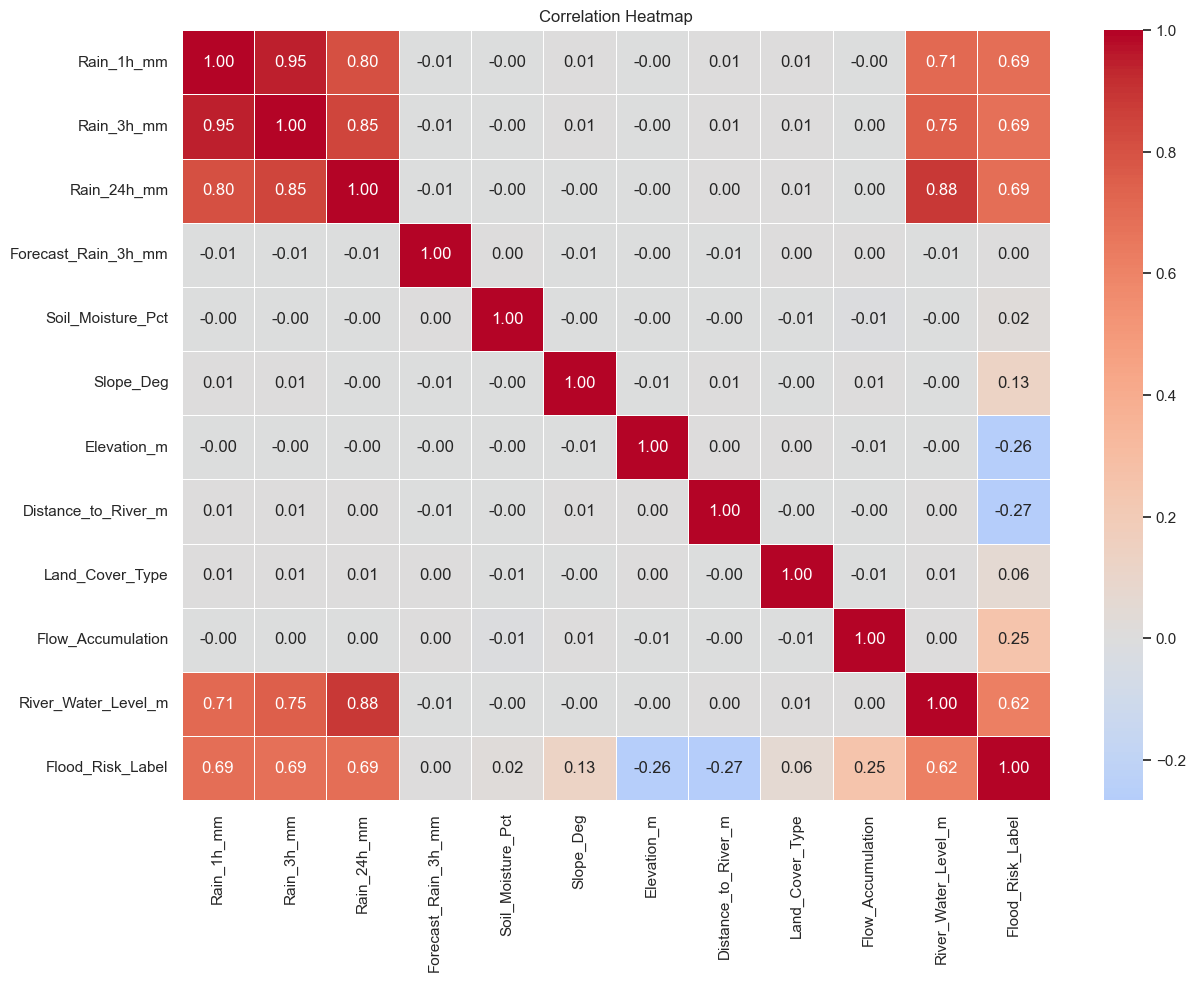

In [22]:
# 3. Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = clean_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [23]:
# 4. Most Influential Features (Correlation with Target)
print('--- Most Influential Features on Flood Risk (Ranked) ---')
target_corr = corr['Flood_Risk_Label'].sort_values(ascending=False)
display(target_corr.drop('Flood_Risk_Label'))

--- Most Influential Features on Flood Risk (Ranked) ---


Rain_24h_mm            0.692015
Rain_1h_mm             0.690640
Rain_3h_mm             0.688154
River_Water_Level_m    0.623708
Flow_Accumulation      0.254969
Slope_Deg              0.130143
Land_Cover_Type        0.062357
Soil_Moisture_Pct      0.023891
Forecast_Rain_3h_mm    0.001487
Elevation_m           -0.257645
Distance_to_River_m   -0.265894
Name: Flood_Risk_Label, dtype: float64

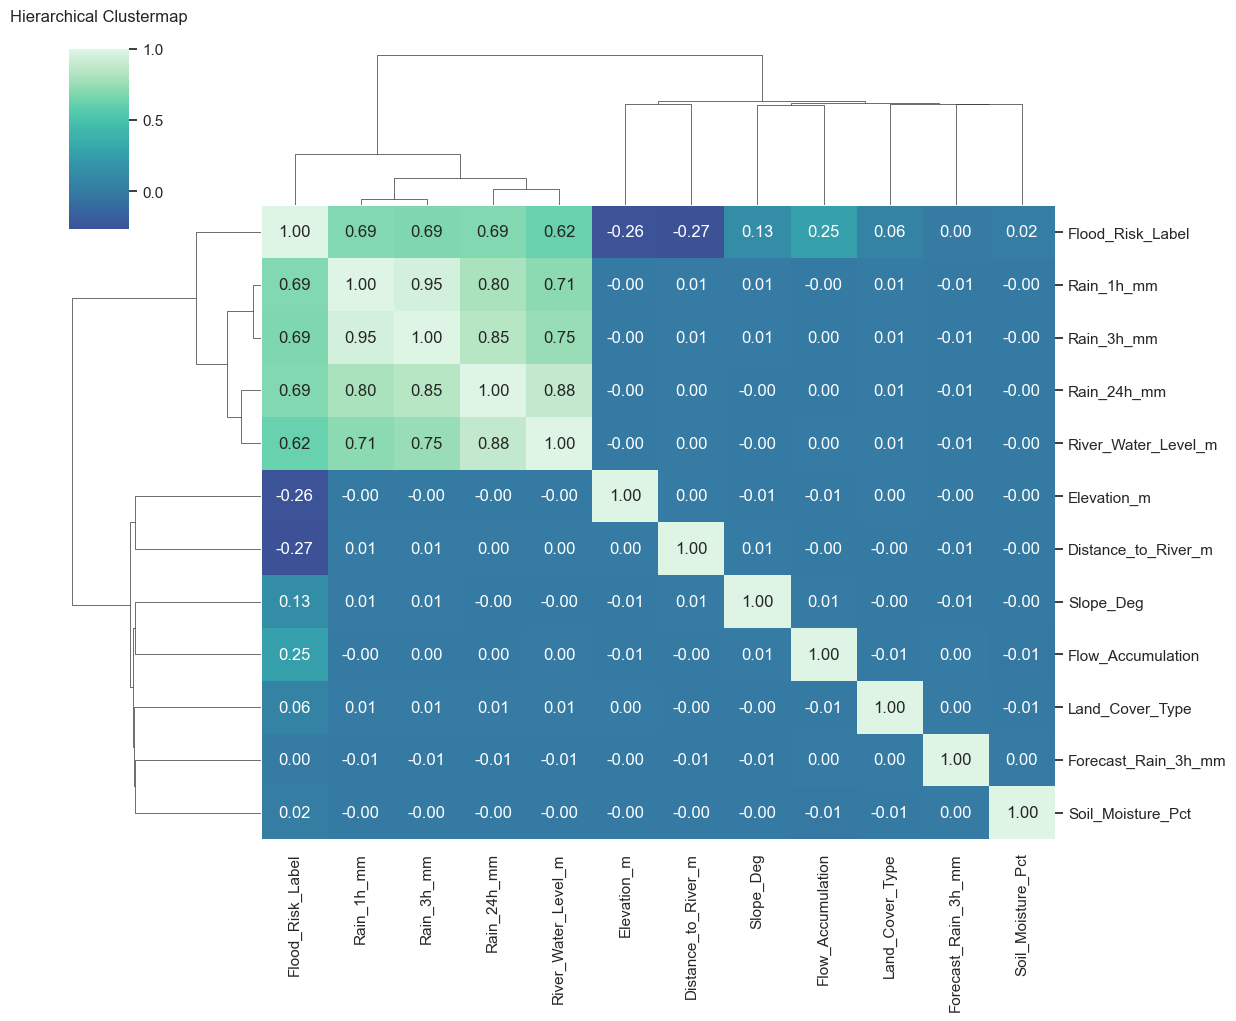

In [24]:
# 5. Cluster Map
sns.clustermap(corr, annot=True, fmt='.2f', cmap='mako', figsize=(12, 10), center=0)
plt.title('Hierarchical Clustermap', pad=20)
plt.show()

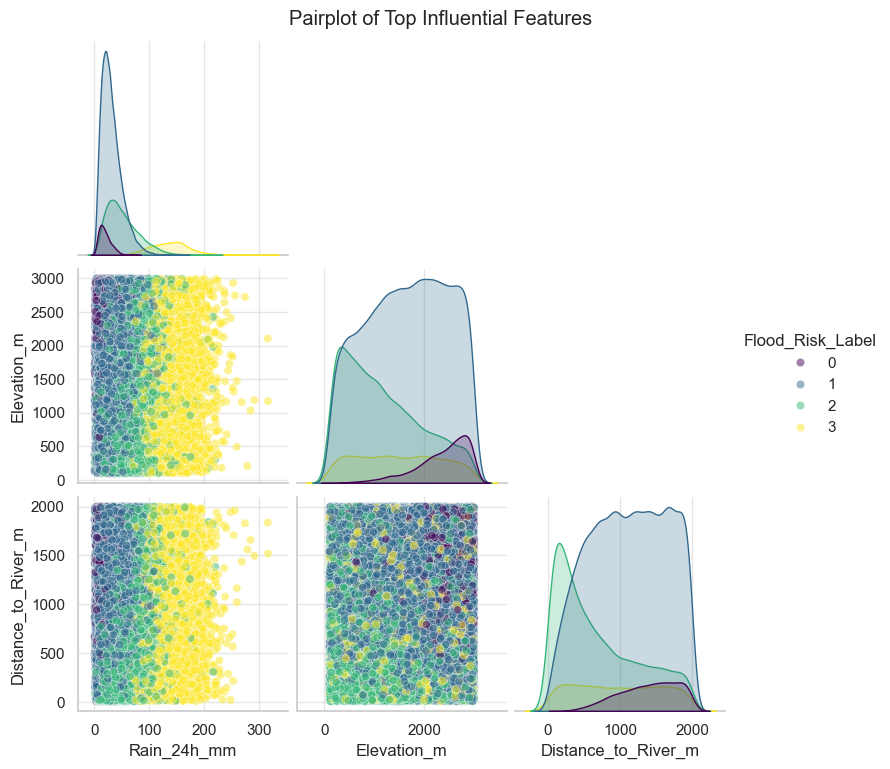

In [25]:
# 6. Pair Plot (Key Features)
# We select the top influential features to avoid an unreadable 13x13 grid
key_features = ['Rain_24h_mm', 'Elevation_m', 'Distance_to_River_m', 'Flood_Risk_Label']
sns.pairplot(clean_df[key_features], hue='Flood_Risk_Label', palette='viridis', corner=True, plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Top Influential Features', y=1.02)
plt.show()

## 1.7 Conclusion: Executive Summary of EDA Insights
Based on our comprehensive exploratory data analysis, we have derived the following critical insights that will directly guide our Feature Engineering and Modeling strategies:

1. **Data Sabotage & Integrity (The Sentinels)**: The dataset contains intentional hardware failure simulations (`-999.0` for broken river sensors and `9999.9` for crashed rain APIs). These must be aggressively mapped to `NaN` and imputed. Additionally, `Risk_Score_Raw` is a direct mathematical leak and must be dropped before training.
2. **Severe Class Imbalance**: The target variable (`Flood_Risk_Label`) is highly skewed. The critical `Level 3 (Evacuate)` class only makes up ~8.4% of the data. Standard algorithms will fail without intervention; we must use stratified splitting and heavily weight the minority class (e.g., via `scale_pos_weight` in XGBoost) to prevent false negatives.
3. **The Physics Engine is Intact**: The correlation and bivariate analyses mathematically prove the dataset obeys real-world hydrology:
   - **Rainfall (Positive Correlation)**: `Rain_24h_mm` is the strongest positive predictor of a flood.
   - **Elevation (Negative Correlation)**: `Elevation_m` is the strongest negative predictor. Floods happen in the valleys, not on the peaks.
   - **Proximity**: `Distance_to_River_m` shows strong negative correlation; danger clusters heavily on the riverbanks.
4. **Outliers and Scales**: The Box Plots and Density Curves reveal massive scale differences (e.g., Elevation stretches into the thousands, while Soil Moisture is capped at 100). Robust feature scaling (`StandardScaler`) is absolutely mandatory for distance-based models.
5. **Interaction Potential**: Because variables like Rain, Elevation, and Slope independently drive flood risk, creating explicit combination variables (like `Rain * Soil Moisture` for Runoff) will significantly boost baseline model accuracy.